![logo](./figures/LogoLine_horizon_C3S.png)

# Consecutive Dry Days with bias adjusted precipitation

This Jupyter Notebook calculates the variable **cdd** (Annual maximum consecutive dry days -below 1 mm-) with bias adjustment (ba) using the ISIMIP trend preserving method based on ([Lange 2019](https://doi.org/10.5194/gmd-12-3055-2019)) (**cddbaismip**) for the CMIP6-CMCC_ESM2 model. **WFDE5** is used as reference dataset for the "ba". 

For quick demonstration purposes, a small region in the north of Spain is selected.

First, the raw CMIP6 model and the reference dataset (WFDE5) needed for bias adjustment are downloaded from the CDS. Then, the CMIP6 model is bias-adjusted, and the results are compared with the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview), which is also downloaded from the CDS.

**<span style="color:red">Please be advised that downloading the required data for this script may take several minutes.</span>**

### Load Python packages and clone and install the c3s-atlas GitHub repository from the ecmwf-projects

Clone (`git clone`) the [c3s-atlas](https://github.com/ecmwf-projects/c3s-atlas) repository and install it (`pip install -e .`).

Further details on how to clone and install the repository are available in the [requirements section](https://github.com/ecmwf-projects/c3s-atlas?tab=readme-ov-file#requirements)

In [57]:
import cdsapi
import os
from pathlib import Path
import xarray as xr
import xclim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
from ibicus.debias import ISIMIP
import scipy
import matplotlib.pyplot as plt

from c3s_atlas.utils import (
    extract_zip_and_delete,
    get_ds_to_fill,
    plot_month
)
from c3s_atlas.fixers import (
    apply_fixers
)
import c3s_atlas.interpolation as xesmfCICA

### Download climate data with the CDS API
To reduce data size and download time, a geographical subset focusing on a specific area within the European region (Spain) is selected.

Catalogues:
- [CMIP6 climate projections](https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=overview)
- [WFDE5](https://cds.climate.copernicus.eu/datasets/derived-near-surface-meteorological-variables?tab=overview): Note that for WFDE5, the subsetting function is not available on the CDS side. To limit the saved data, the entire global dataset is downloaded and then cropped to the Spanish area.

> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials — such as `cdsapi_url` and `cdsapi_key` — directly in notebooks.
>
> Instead, it is best to store them securely in a `.cdsapirc` file located in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [85]:
cdsapi_url= "https://cds.climate.copernicus.eu/api"
cdsapi_key= ""

In [59]:
c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

Running the code blocks bellow will download the data from the CDS as specified by the following API keywords:

**Project:** `CMIP6 (Coupled Model Intercomparison Project Phase 6)`\
**Variables:** `Precipitation`   
**Temporal Resolution:** `Daily`  
**Model:** `CMCC-ESM2`  
**Experiment:** `Historical; SSP5-8.5`  
**Period:** `1980-2006; 2015-2100`  
**Month:** `All`  
**Day:** `All`  

In [60]:
# define some global attributes for the CDS-API
CMIP6_years = {
    "historical": [str(n) for n in np.arange(1980, 2006)],
    "ssp5_8_5": [str(n) for n in np.arange(2015, 2100)]
}
# variables
variables = {
    'pr': 'precipitation',
}
# directory to download the files
file_dest_CMIP6 = Path('./data/CMIP6')
file_dest_WFDE5 = Path('./data/WFDE5')

In [61]:
# define some global attributes for the CDS-API
CMIP6_years = {
    "ssp5_8_5": [str(n) for n in np.arange(2040, 2100)]
}
# variables
variables = {
    'pr': 'precipitation',
}
# directory to download the files
file_dest_CMIP6 = Path('./data/CMIP6')
file_dest_WFDE5 = Path('./data/WFDE5')

In [62]:
months = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12'
]
        
days = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12',
    '13', '14', '15',
    '16', '17', '18',
    '19', '20', '21',
    '22', '23', '24',
    '25', '26', '27',
    '28', '29', '30', '31'
]

#### Download CMIP6 data 
- Period 2015-2100 for the ssp5_8_5 scenario
- Period 1980-2006 for the historical scenario.

In [ ]:
os.makedirs(file_dest_CMIP6, exist_ok=True)

for experiment in CMIP6_years.keys():
    for year in CMIP6_years[experiment]:
        for var in variables.keys():
            path_zip = file_dest_CMIP6 / f"CMIP6_{var}_{experiment}_{year}.zip"
            c.retrieve(
                'projections-cmip6',
                {
                    'temporal_resolution': 'daily',
                    'variable': variables[var],
                    'experiment': experiment,
                    'model': 'cmcc_esm2',
                    'year': [year],
                    'month': months,
                    'day': days,
                    'area':[45.5, 5.5, 34, -11.5], # crop area for Spain
                }).download(path_zip)
            # Extract zip file into the specified directory and remove zip
            extract_zip_and_delete(path_zip) 

#### Download WFDE5 data 
- Period 1980-2006

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `WFDE5 (WATCH Forcing Data methodology applied to ERA5)`\
**Version:** `2.1`\   
**Reference Dataset:** `cru`\
**Variables:** `precipitation`   
**Period:** `1980-2006`  
**Month:** `All`  

In [63]:
# variables
variables = {
    'pr': 'rainfall_flux',
}

In [ ]:
os.makedirs(file_dest_WFDE5, exist_ok=True)

for year in CMIP6_years['historical']:
    for month in months:
        for var in variables.keys():
            path_zip = file_dest_WFDE5 / f"WFDE5_{var}_{year}_{month}_globe.zip"
            c.retrieve(
                'derived-near-surface-meteorological-variables',
                {
                    'version': '2_1',
                    'month': month,
                    'reference_dataset': 'cru',
                    'variable': variables[var],
                    'year': year,
                }).download(path_zip)
            # Extract zip file into the specified directory and remove zip
            extract_zip_and_delete(path_zip)
            # Crop area an save
            ds = xr.open_dataset(path_zip.with_suffix(".nc"))
            ds = ds.sel(lat = slice(34, 45.5), lon = slice(-11.5 , 5.5))
            file = file_dest_WFDE5 / f"WFDE5_{var}_{year}_{month}.nc"
            ds.to_netcdf(file)
            os.remove(path_zip.with_suffix(".nc"))

### Load files with xarray

- https://docs.xarray.dev/en/stable/

In [ ]:
# load CMIP6 files
ds_CMIP6_hist = xr.open_mfdataset(
    np.sort(glob.glob(str(file_dest_CMIP6 / "*pr_historical*.nc"))), 
    concat_dim='time', combine='nested'
)

ds_CMIP6_ssp585 = xr.open_mfdataset(
    np.sort(glob.glob(str(file_dest_CMIP6 / "*pr_ssp5_8_5*.nc"))), 
    concat_dim='time', combine='nested'
)
# load WFDE5 files
ds_WFDE5_hist = xr.open_mfdataset(
    np.sort(glob.glob(str(file_dest_WFDE5 / "*WFDE5_pr*.nc"))), 
    concat_dim='time', combine='nested'
)

#### Visualize downloaded datasets

Text(0.5, 0.98, 'Mean Precipitation 1980-2005 (kg.m/s²)')

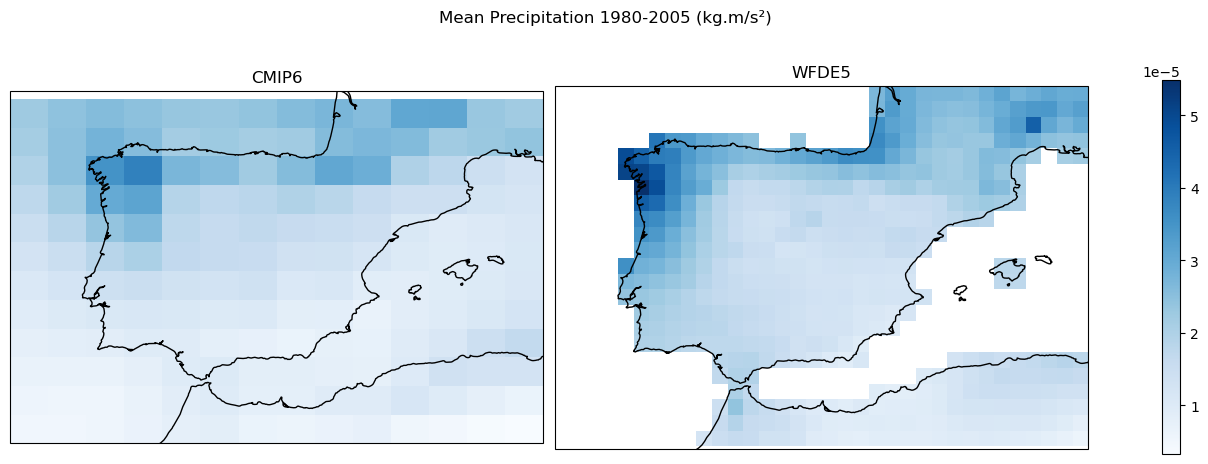

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, 
                        subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

data_cmip6 = ds_CMIP6_hist['pr'].sel(
    time=slice('1980-01-01', '2005-12-31')).mean(dim = 'time')
data_wfde5 = ds_WFDE5_hist['Rainf'].sel(
    time=slice('1980-01-01', '2005-12-31')).mean(dim = 'time')

vmin = min(data_cmip6.min(), data_wfde5.min()).values
vmax = max(data_cmip6.max(), data_wfde5.max()).values

data_cmip6.plot(ax=axes[0], cmap="Blues", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[0].set_title("CMIP6")
axes[0].coastlines()

data_wfde5.plot(ax=axes[1], cmap="Blues", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[1].set_title("WFDE5")
axes[1].coastlines()

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(vmin=vmin, vmax=vmax)), 
                    ax=axes, orientation='vertical', shrink=0.8)
fig.suptitle("Mean Precipitation 1980-2005 (kg.m/s²)")

### Homogenization

Once the data is downloaded from the CDS it undergoes a process of homogenization (see the ["Homogenization"](https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/README.md) section for more details). 

- `dataset_variable`: Renames the variable using, respectively, the original (raw) variable name and the corresponding C3S Atlas variable name provided as inputs.
- `aggregation`: Specifies the aggregation function applied to resample the data to either monthly or daily temporal resolution.

In [14]:
project_id = "cmip6"
variable = 'pr'
var_mapping = {
            "dataset_variable": {"pr": "pr"},
            "aggregation": {"pr": "mean"},
        }
ds_CMIP6_hist = apply_fixers(ds_CMIP6_hist, variable, project_id, var_mapping)
ds_CMIP6_ssp585 = apply_fixers(ds_CMIP6_ssp585, variable, project_id, var_mapping)

2026-02-23 09:28:47,231 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-23 09:28:47,290 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 11MB
Dimensions:    (time: 9490, bnds: 2, lat: 12, lon: 14)
Coordinates:
  * time       (time) object 76kB 1980-01-01 12:00:00 ... 2005-12-31 12:00:00
  * lat        (lat) float64 96B 34.4 35.34 36.28 37.23 ... 42.88 43.82 44.76
  * lon        (lon) float64 112B -11.25 -10.0 -8.75 -7.5 ... 1.25 2.5 3.75 5.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 152kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 2MB dask.array<chunksize=(365, 12, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 2MB dask.array<chunksize=(365, 14, 2), meta=np.ndarray>
    pr         (time, lat, lon) float32 6MB dask.array<chunksize=(1, 12, 14), meta=np.ndarray>
Attributes: (12/48)
    Conventions:           

In [20]:
project_id = "WFDE5"
variable = 'pr'
var_mapping = {
            "dataset_variable": {"pr": "Rainf"},
            "aggregation": {"pr": "mean"},
        }
ds_WFDE5_hist = apply_fixers(ds_WFDE5_hist, variable, project_id, var_mapping)

2026-02-23 09:44:00,042 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-23 09:44:00,134 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 715MB
Dimensions:  (time: 227928, lat: 23, lon: 34)
Coordinates:
  * lat      (lat) float64 184B 34.25 34.75 35.25 35.75 ... 44.25 44.75 45.25
  * lon      (lon) float64 272B -11.25 -10.75 -10.25 -9.75 ... 4.25 4.75 5.25
  * time     (time) datetime64[ns] 2MB 1980-01-01 ... 2005-12-31T23:00:00
Data variables:
    Rainf    (time, lat, lon) float32 713MB dask.array<chunksize=(744, 23, 34), meta=np.ndarray>
Attributes:
    title:        WATCH Forcing Data methodology applied to ERA5 data
    institution:  Copernicus Climate Change Service
    contact:      http://copernicus-support.ecmwf.int
    comment:      Methodology implementation for ERA5 and dataset production ...
    Conventions:  CF-1.7
    summary:      ERA5 data regridded to half degree regular lat-lon; Genuine...
  

### Interpolation to a common and regular grid using xESMF 
A wrapper for the [xESMF](https://xesmf.readthedocs.io/en/stable/) Python package was developed within the framework of the C3S Atlas project to extend its functionalities to all datasets (regular, curvilinear, etc.)

In [22]:
# interpolate data
int_attr = {'interpolation_method' : 'conservative_normed', 
            'lats' : np.arange(34.5, 46.5, 1),
            'lons' : np.arange(-11.5, 6.5, 1),
            'var_name' : 'pr'
}

In [23]:
INTER = xesmfCICA.Interpolator(int_attr)

In [24]:
ds_CMIP6_hist_i = INTER(ds_CMIP6_hist)
ds_CMIP6_ssp585_i = INTER(ds_CMIP6_ssp585)
ds_WFDE5_hist_i = INTER(ds_WFDE5_hist)

#### Crop small area in the north of Spain

In [25]:
ds_CMIP6_hist_i = ds_CMIP6_hist_i.sel(lon = slice(-5, -1), lat = slice(42, 46))
ds_CMIP6_ssp585_i = ds_CMIP6_ssp585_i.sel(lon = slice(-5, -1), lat = slice(42, 46))
ds_WFDE5_hist_i = ds_WFDE5_hist_i.sel(lon = slice(-5, -1), lat = slice(42, 46))

Text(0.5, 0.98, 'Mean Precipitation 1980-2005 (kg.m/s²)')

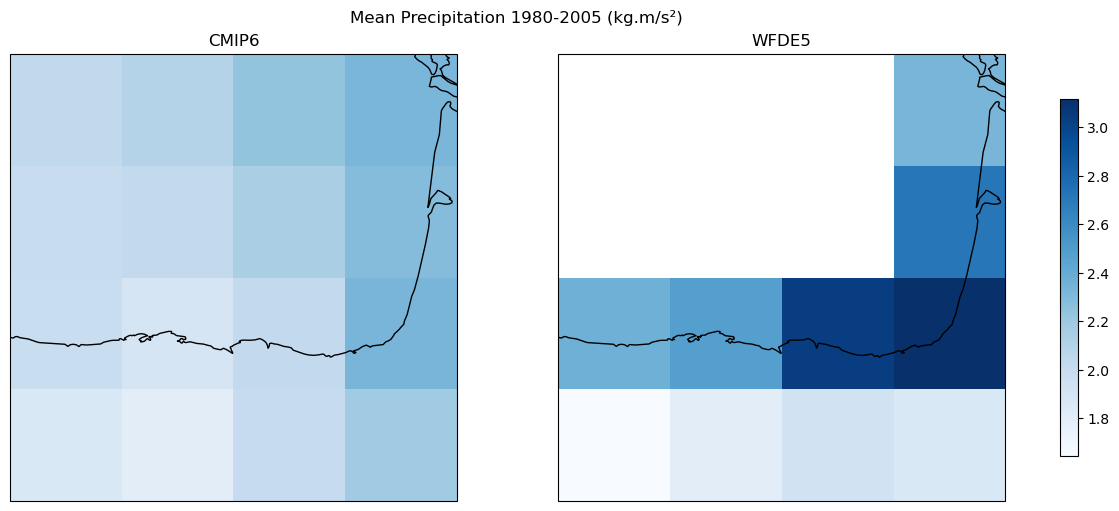

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, 
                        subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

data_cmip6 = ds_CMIP6_hist_i['pr'].sel(
    time=slice('1980-01-01', '2005-12-31')).mean(dim = 'time')
data_wfde5 = ds_WFDE5_hist_i['pr'].sel(
    time=slice('1980-01-01', '2005-12-31')).mean(dim = 'time')

vmin = min(data_cmip6.min(), data_wfde5.min()).values
vmax = max(data_cmip6.max(), data_wfde5.max()).values

data_cmip6.plot(ax=axes[0], cmap="Blues", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[0].set_title("CMIP6")
axes[0].coastlines()

data_wfde5.plot(ax=axes[1], cmap="Blues", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[1].set_title("WFDE5")
axes[1].coastlines()

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes, orientation='vertical', shrink=0.8)
fig.suptitle("Mean Precipitation 1980-2005 (kg.m/s²)")

### Bias adjustment using ibicus
Two methods of **ba** are applied in the C3S Atlas: the [LinearScaling](https://ibicus.readthedocs.io/en/latest/reference/debias.html#ibicus.debias.LinearScaling) ([Douglas Maraun 2016](https://doi.org/10.1007/s40641-016-0050-x)) and the [ISIMIP](https://ibicus.readthedocs.io/en/latest/reference/debias.html#ibicus.debias.ISIMIP) ([Lange 2019](https://doi.org/10.5194/gmd-12-3055-2019)). Here, for simplicity, we applied the linear scaling one.

- https://pypi.org/project/ibicus/

In [67]:
args = {
    "lower_bound": 0,
    "lower_threshold": 0.1,
    "upper_bound": np.inf,
    "upper_threshold": np.inf,
    "distribution": scipy.stats.gamma,
    "trend_preservation_method": "mixed",
    "running_window_mode" : False,
    "impute_missing_values": True,
}

debiaser_obj = ISIMIP.from_variable(
    variable = 'pr', 
    **args
)

In [ ]:
ba_data = debiaser_obj.apply(
    obs = ds_WFDE5_hist_i['pr'].sel(
        time = slice('1980-01-01', '2005-12-31')).values,
    cm_hist = ds_CMIP6_hist_i['pr'].sel(
        time = slice('1980-01-01', '2005-12-31')).values,
    cm_future = ds_CMIP6_ssp585_i['pr'].values,
)

In [ ]:
ds_bias = get_ds_to_fill("prbaisimip", target = ds_CMIP6_ssp585_i, reference = ds_CMIP6_ssp585_i)
ds_bias = ds_bias.transpose("time", "lat", "lon")
ds_bias["prbaisimip"][:] = ba_data
ds_bias["prbaisimip"].attrs["units"] = "mm/day" # xclim needs the atrribute units

### Calculate index (cdd) and aggregate to yearly (YS) temporal resolution using xclim

[xclim](https://xclim.readthedocs.io/en/stable/) is an operational Python library for climate services, providing a framework for constructing custom climate indicators and indices.

In [ ]:
da_cddbaisimip = xclim.indices.maximum_consecutive_dry_days(ds_bias["prbaisimip"],
                                                            thresh='1 mm/day', 
                                                            freq='YS', 
                                                            resample_before_rl=True)

"freq" attribute indicates output time frequency following [pandas timeserie codes](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects)

In [ ]:
# Convert DataArray to Dataset with specified variable name
da_cddbaisimip = da_cddbaisimip.to_dataset(name='cddbaisimip')

## Compare the results with the "Gridded dataset underpinning the Copernicus Interactive Climate Atlas"

- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Annual maximum consecutive dry days`\  
**Bias adjustment:** `ISIMIP` \
**Origin:** `CMIP6`  
**Experiment:** `SSP5-8.5`  
**Period:** `2015–2100`  
**Area:** `[46, -5, 42, −1]` (Cropped over Spain)

In [ ]:
project = "CMIP6"
scenario = "ssp585"
var = 'cdd'
# directory to download the files
dest = Path('./data/CMIP6')
os.makedirs(dest, exist_ok=True)

##### Download SSP scenario

In [ ]:
filename = 'cddbaisimip_CMIP6_ssp585_mon_2015-2100.zip'
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "cmip6",
    "experiment": "ssp5_8_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "annual_maximum_consecutive_dry_days",
    "bias_adjustment": "isimip_method",
    'area': [46, -5, 42, -1]
}
c.retrieve(dataset, request).download(dest / filename)
extract_zip_and_delete(dest / filename) 

In [70]:
# load data with xarray
ds_cddbaisimip_C3S_Atlas = xr.open_dataset(dest / "cddbaisimip_CMIP6_ssp585_mon_2015-2100.nc",
                                          decode_timedelta = False)
ds_cddbaisimip_C3S_Atlas = ds_cddbaisimip_C3S_Atlas.sel(lon = slice(-5, -1), lat = slice(42, 46))

In [71]:
# select member (note than member names in the "Copernicus Interactive Climate Atlas: gridded monthly dataset" 
# are remappend to follow the DRS as much as possible)
select_member = [
    str(mem.data) for mem in ds_cddbaisimip_C3S_Atlas.member_id if "cmcc-esm2" in str(mem.data).lower()
][0]
print(select_member)

CMCC_CMCC-ESM2_r1i1p1f1


In [72]:
ds_cddbaisimip_C3S_Atlas_member = ds_cddbaisimip_C3S_Atlas.sel(
    member = np.where(ds_cddbaisimip_C3S_Atlas.member_id == select_member)[0]
)

#### Plot results
Comparison of the results obtained with present Jupyter notebook and the reference [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) underpinning the C3S Atlas. A geographical subset focusing on the north of Spain is selected to show the results.

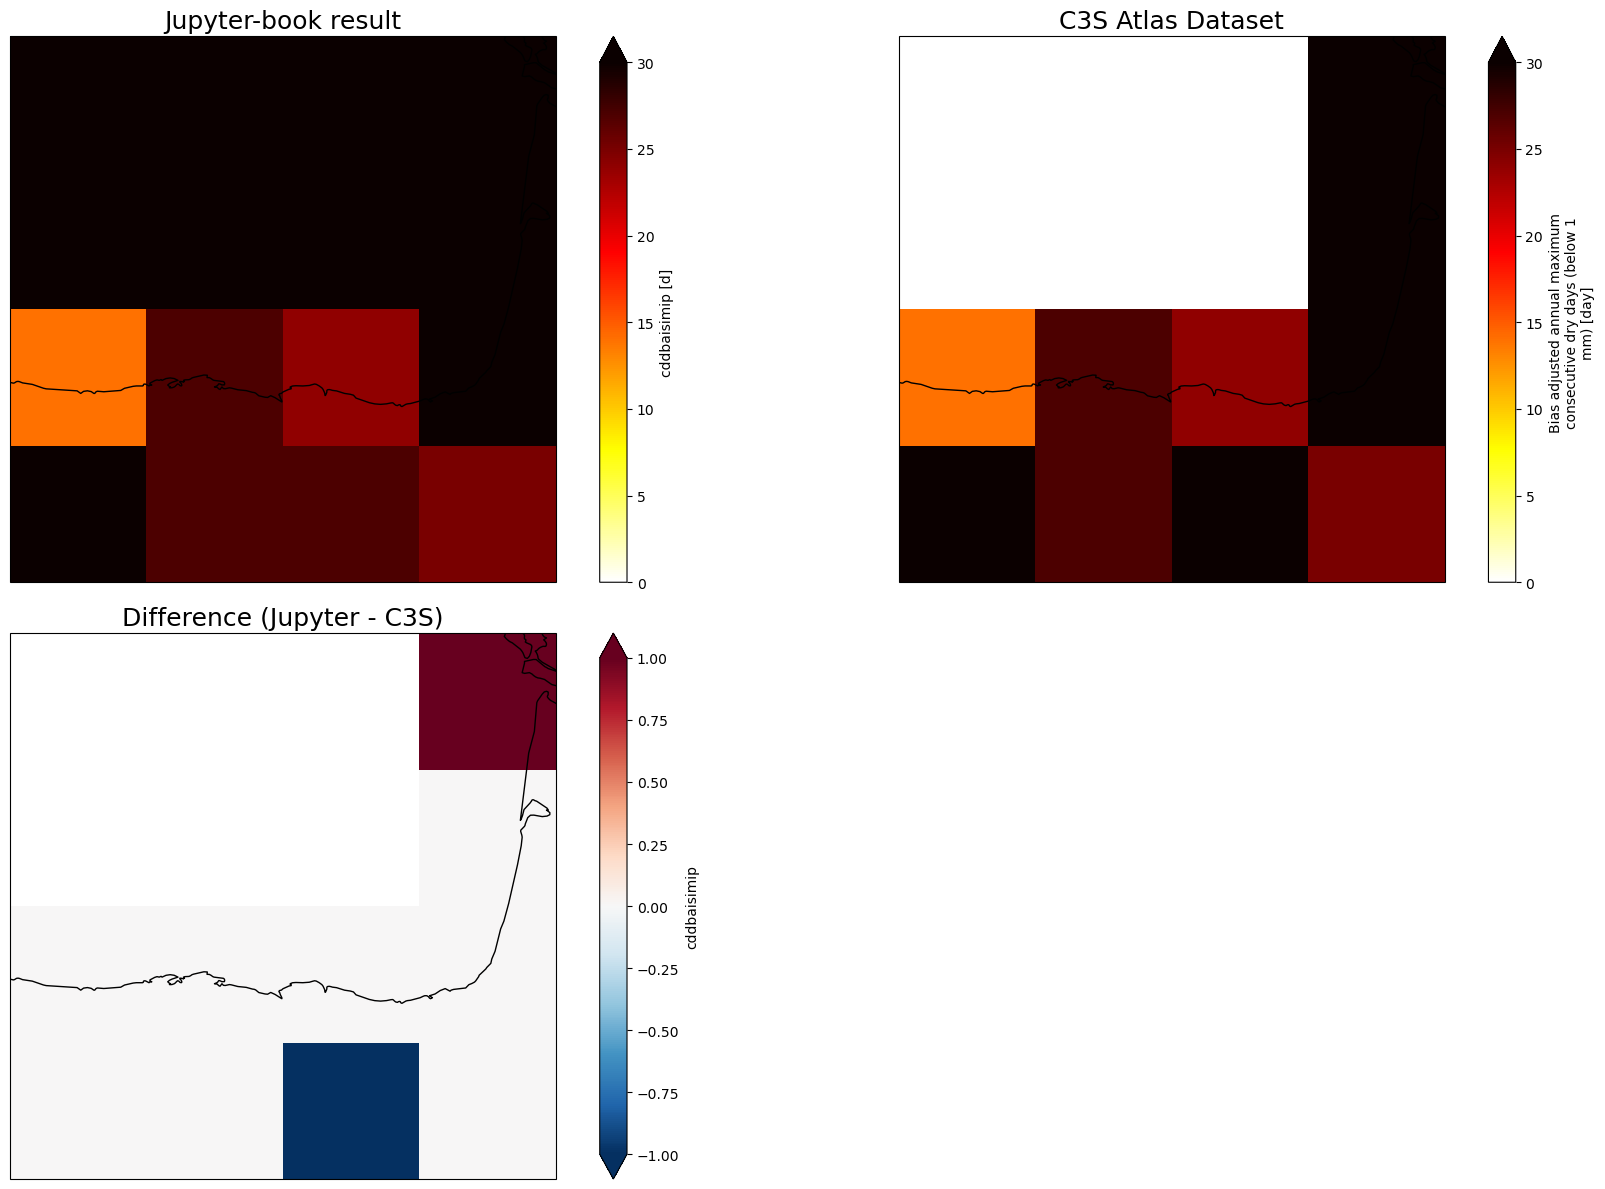

In [80]:
title_size = 18

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    nrows=2, ncols=2,
    subplot_kw={'projection': proj},
    figsize=(18, 12)
)

# calculate climatologies and the difference
diff = da_cddbaisimip['cddbaisimip'] - ds_cddbaisimip_C3S_Atlas_member['cddbaisimip']

# Jupyter-book result
da_cddbaisimip['cddbaisimip'].sel(time = '2020').plot(ax = ax[0, 0], cmap = 'hot_r', vmin = 0, vmax = 30)
ax[0, 0].set_title('Jupyter-book result',  fontsize = title_size)
ax[0, 0].coastlines()

# C3S Atlas Dataset
ds_cddbaisimip_C3S_Atlas_member['cddbaisimip'].sel(time = '2020').plot(ax = ax[0, 1], cmap = 'hot_r',vmin = 0, vmax = 30)
ax[0, 1].set_title('C3S Atlas Dataset',  fontsize = title_size)
ax[0, 1].coastlines()

# Diff
diff.sel(time = '2020').plot(ax = ax[1, 0], cmap = 'RdBu_r', vmin = -1, vmax = 1)
ax[1, 0].set_title("Difference (Jupyter - C3S)", fontsize = title_size)
ax[1, 0].coastlines()
fig.delaxes(ax[1, 1])

plt.tight_layout()
plt.show()

The results are identical, but we have to be careful because the ISIMIP method returns values even in those cells where we do not have data in the reference dataset.